## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
file_path = r"D:\DSML\Week 2\Day 5\LABs\lab-eda-bivariate\amz_uk_price_prediction_dataset.csv"
df = pd.read_csv(file_path)

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


---

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [6]:
# Create the crosstab, calculate the proportion of best-sellers for each category (normalize = "index"), then sort the categories.
crosstab_analysis = pd.crosstab(df["category"], df["isBestSeller"], normalize = "index").sort_values(by = True, ascending = False)
crosstab_analysis

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
Bedding Collections,1.000000,0.000000
CPUs,1.000000,0.000000
"CD, Disc & Tape Players",1.000000,0.000000


In [7]:
from scipy.stats import chi2_contingency

In [8]:
#Let's check if category does influence the isBestSeller
crosstab_analysis_raw = pd.crosstab(df["category"], df["isBestSeller"])

chi2, p_val, _, _ = chi2_contingency(crosstab_analysis_raw)

print(chi2)
print(p_val)

36540.20270061387
0.0


In [9]:
from scipy.stats.contingency import association

In [10]:
#Now that we know it does affect, by how much?
association(crosstab_analysis_raw, method = "cramer")

0.1222829439760564

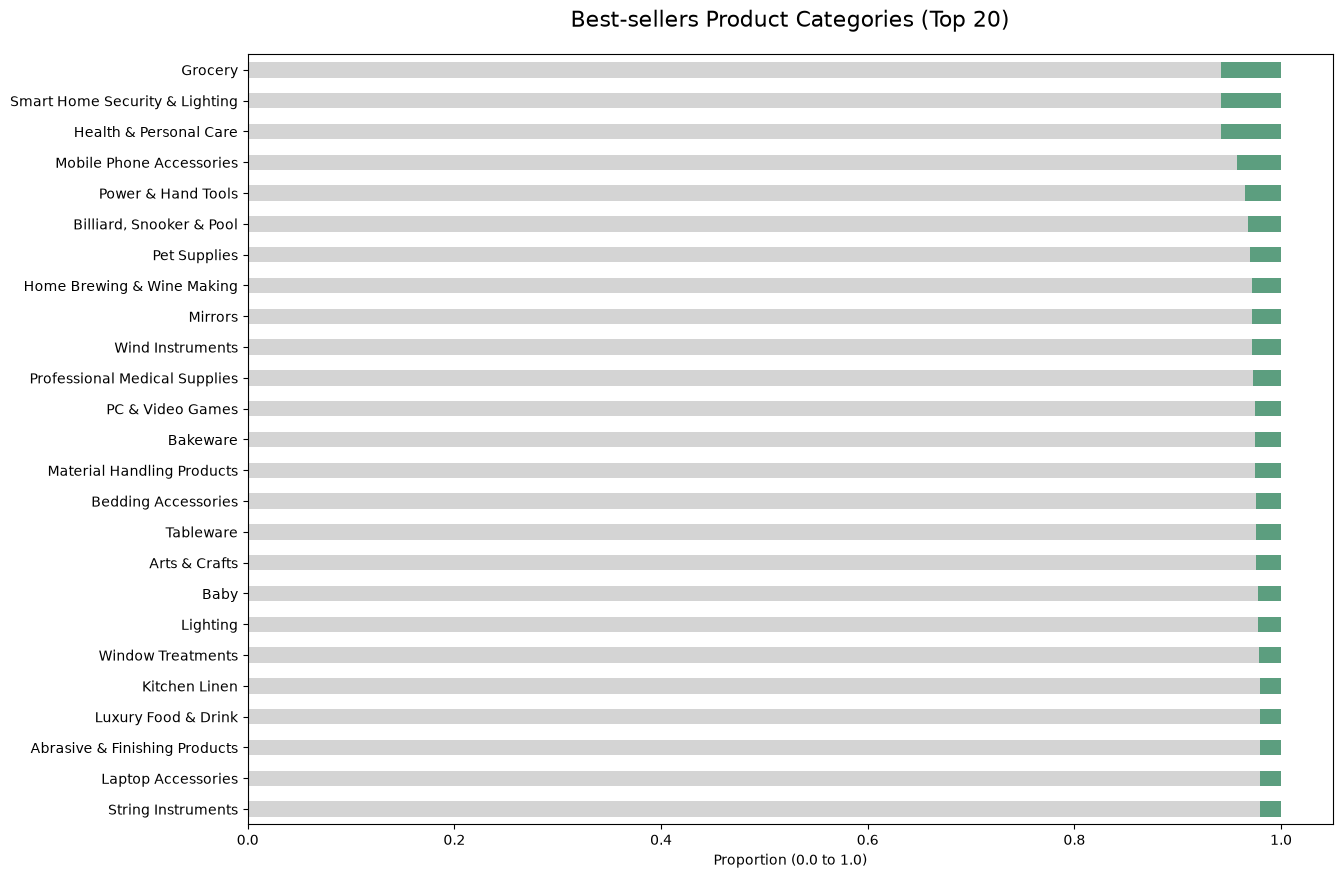

In [11]:
crosstab_analysis.head(25).plot(
    kind = "barh",
    stacked = True,
    legend = False,

    color = ["#D4D4D4", "#5C9E7F"],
    figsize = (14, 10)
)

plt.title(r"Best-sellers Product Categories (Top 20)", fontsize = 16, pad = 20)
plt.ylabel("")
plt.xlabel("Proportion (0.0 to 1.0)")

#plt.legend(["NOT best seller", "Best seller"], frameon = False, bbox_to_anchor = (1, 1))
plt.gca().invert_yaxis()

plt.show()

---

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.


In [12]:
def outlier_slayer(series):
    Q1 = series.quantile(.25)
    Q3 = series.quantile(.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    higher_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > higher_bound)]

    return outliers

In [13]:
df_no_outlier = df[~df["price"].isin(outlier_slayer(df["price"]))] # "~" for doing the exact opposite of the 

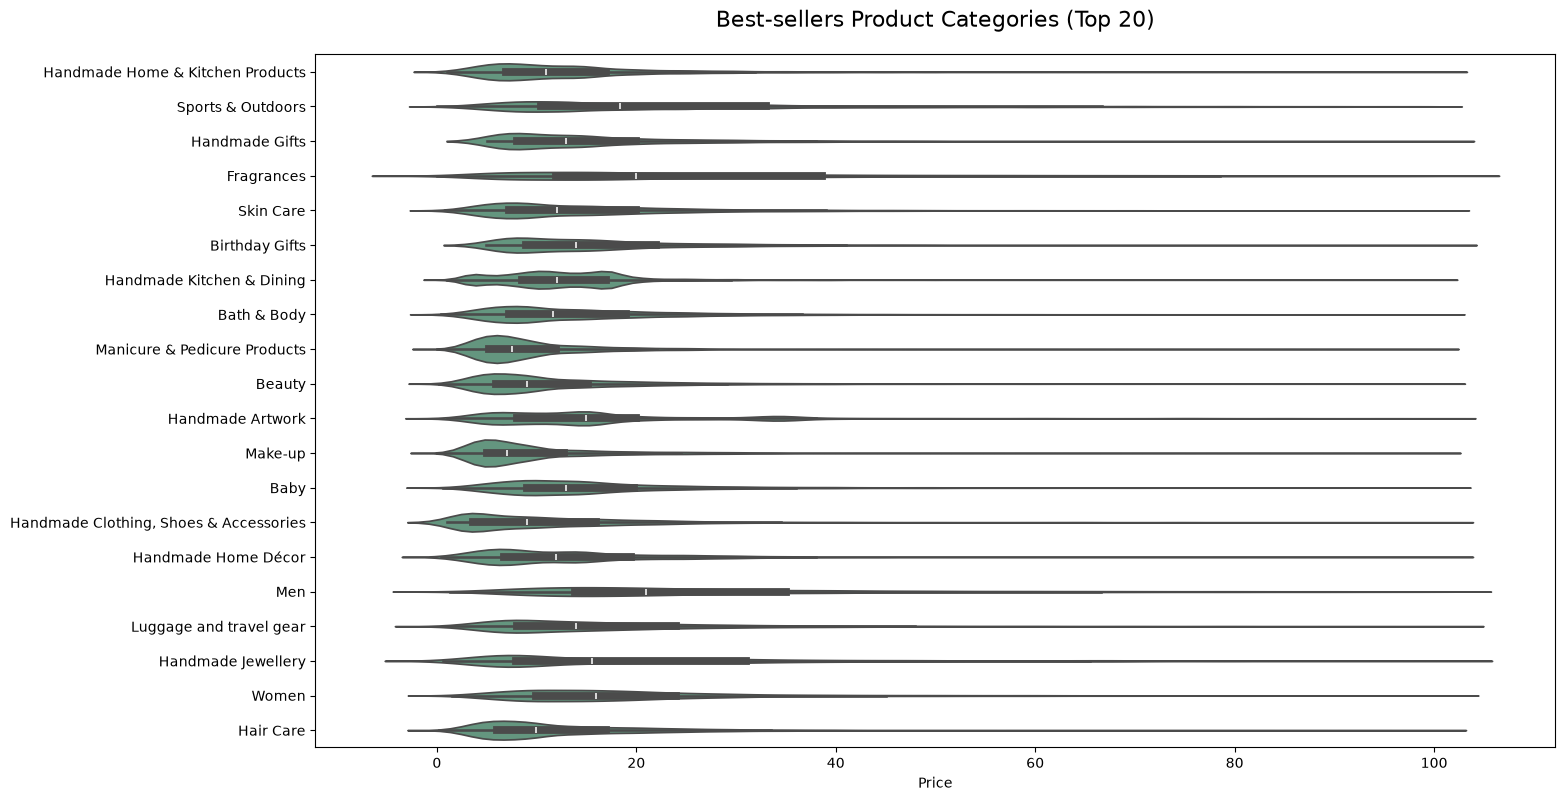

In [14]:
plt.figure(figsize = (16,9))

sns.violinplot(
    data = df_no_outlier[df_no_outlier["category"].isin(df_no_outlier["category"].value_counts().head(20).index)],
    x = "price",
    y = "category",
    color = "#5C9E7F"
)


plt.title(r"Best-sellers Product Categories (Top 20)", fontsize = 16, pad = 20)
plt.ylabel("")
plt.xlabel("Price")

plt.show()

In [15]:
median_price_sorting = df_no_outlier.groupby("category")["price"].median().sort_values(ascending = False)
median_price_sorting    #Desktop PCs has the highest median price

category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

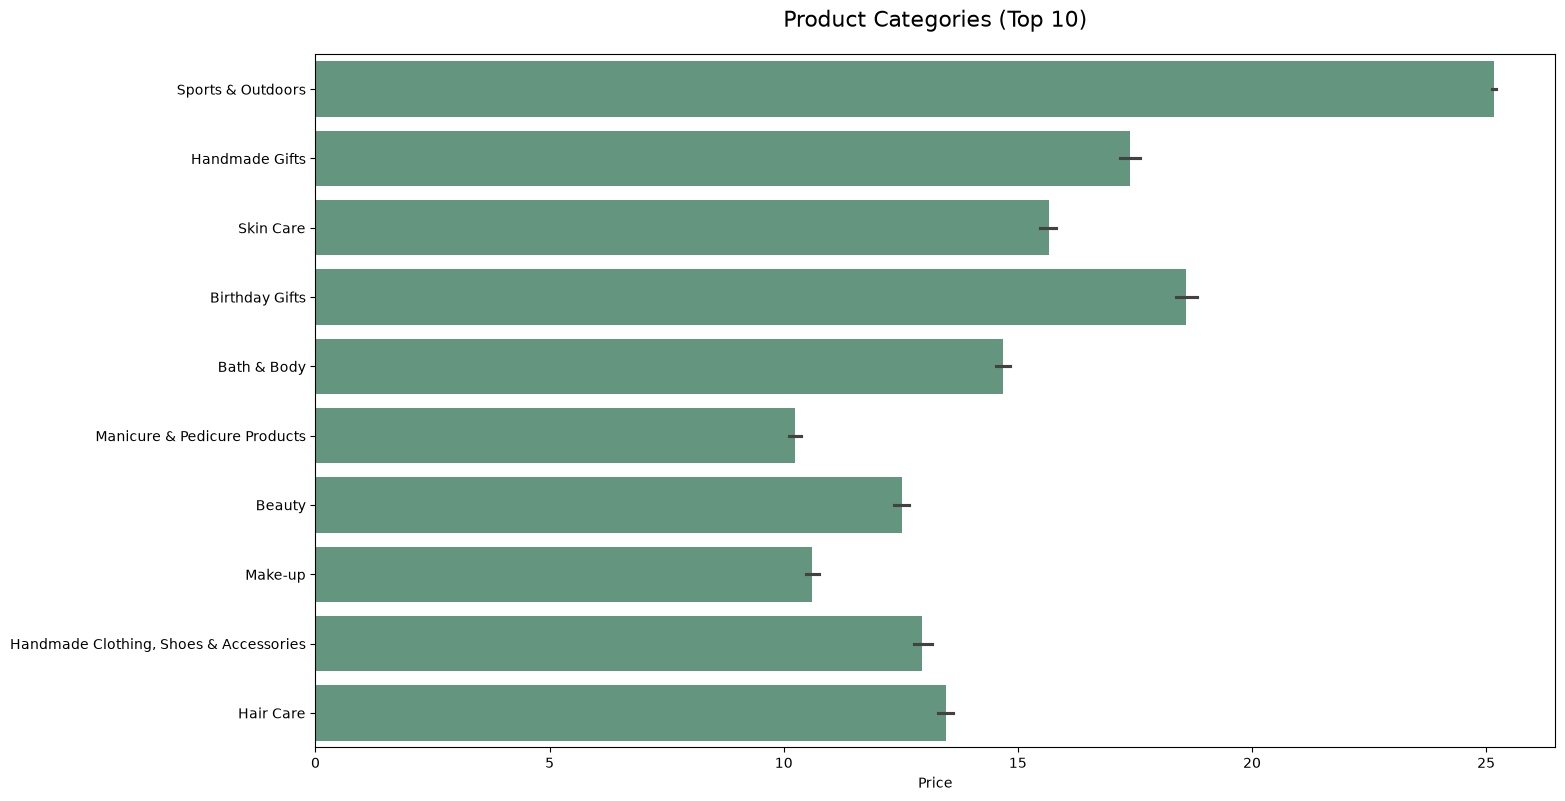

In [16]:
plt.figure(figsize = (16,9))

sns.barplot(
    data = df_no_outlier[df_no_outlier["category"].isin(df_no_outlier["category"].value_counts().head(10).index)],
    x = "price",
    y = "category",
    color = "#5C9E7F"
)

plt.title(r"Product Categories (Top 10)", fontsize = 16, pad = 20)
plt.ylabel("")
plt.xlabel("Price")

plt.show()

In [17]:
mean_price_sorting = df_no_outlier.groupby("category")["price"].mean().sort_values(ascending = False)
mean_price_sorting    #Motherboards has the highest mean price

category
Motherboards             68.772432
Boxing Shoes             67.417803
Desktop PCs              66.915562
Tablets                  66.552971
Graphics Cards           65.103509
                           ...    
Bedding Accessories       8.835220
Adapters                  8.750197
Signs & Plaques           8.210513
Arts & Crafts             8.006540
Office Paper Products     6.876369
Name: price, Length: 296, dtype: float64

In [18]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')

In [19]:
clean_rating = df_no_outlier[df_no_outlier["stars"] > 0]

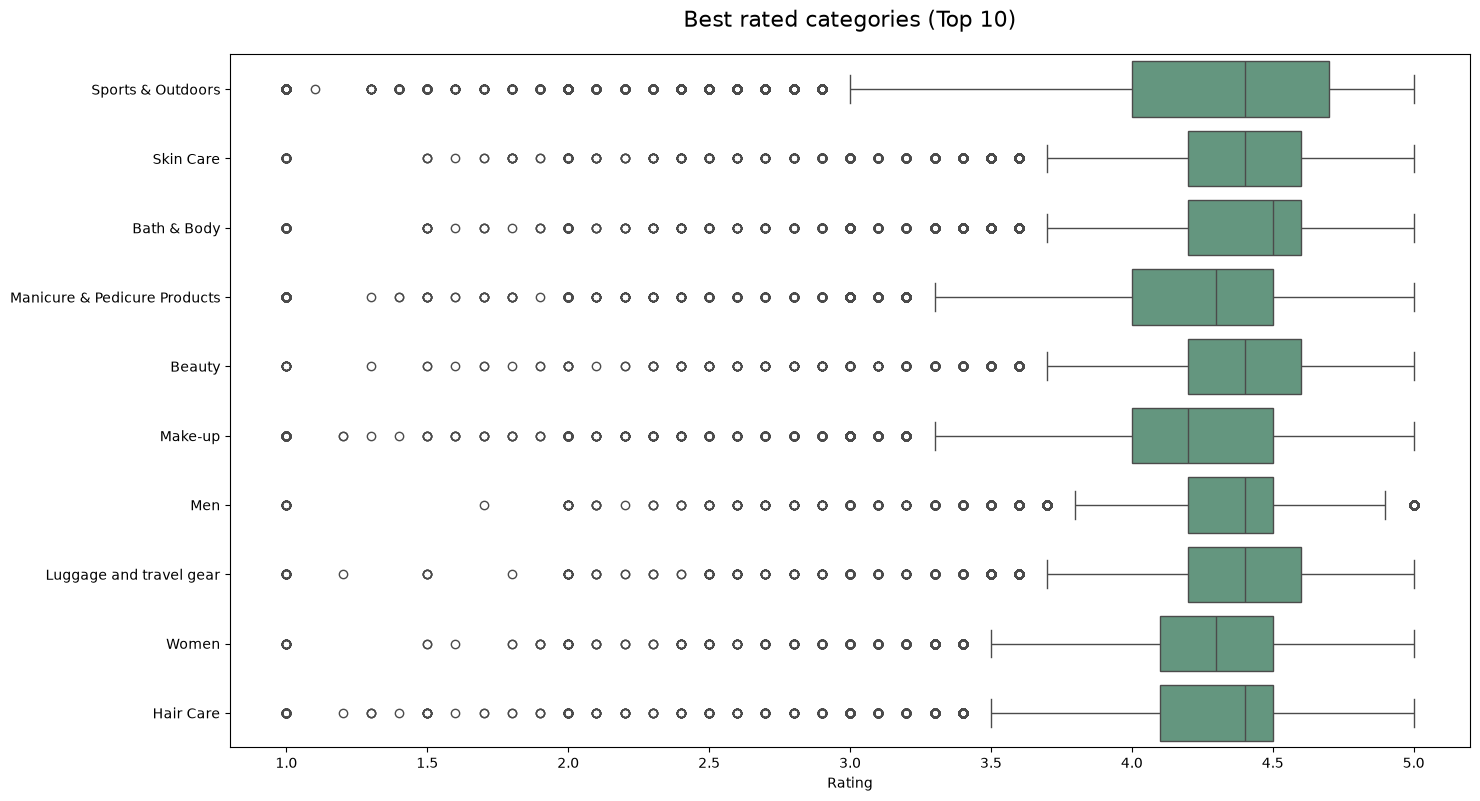

In [20]:
plt.figure(figsize = (16,9))

sns.boxplot(
    data = clean_rating[clean_rating["category"].isin(clean_rating["category"].value_counts().head(10).index)],
    x = "stars",
    y = "category",
    color = "#5C9E7F"
)

plt.title(r"Best rated categories (Top 10)", fontsize = 16, pad = 20)
plt.ylabel("")
plt.xlabel("Rating")

plt.show()

In [21]:
median_rating = clean_rating.groupby("category")["stars"].median().sort_values(ascending = False)
median_rating    #Handmade Artwork is the best rated category

category
Handmade Artwork                          5.0
Made in Italy Handmade                    5.0
Handmade Baby Products                    5.0
Handmade Clothing, Shoes & Accessories    4.9
Handmade Kitchen & Dining                 4.9
                                         ... 
Mobile Phones & Smartphones               3.9
Camcorders                                3.8
Media Streaming Devices                   3.8
Action Cameras                            3.8
Motorbike Instruments                     3.7
Name: stars, Length: 296, dtype: float64

---

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

In [22]:
rating_price_correlation = clean_rating["price"].corr(clean_rating["stars"])
print(f"Correlation between price and stars is: {rating_price_correlation:.4f}")

Correlation between price and stars is: 0.0067


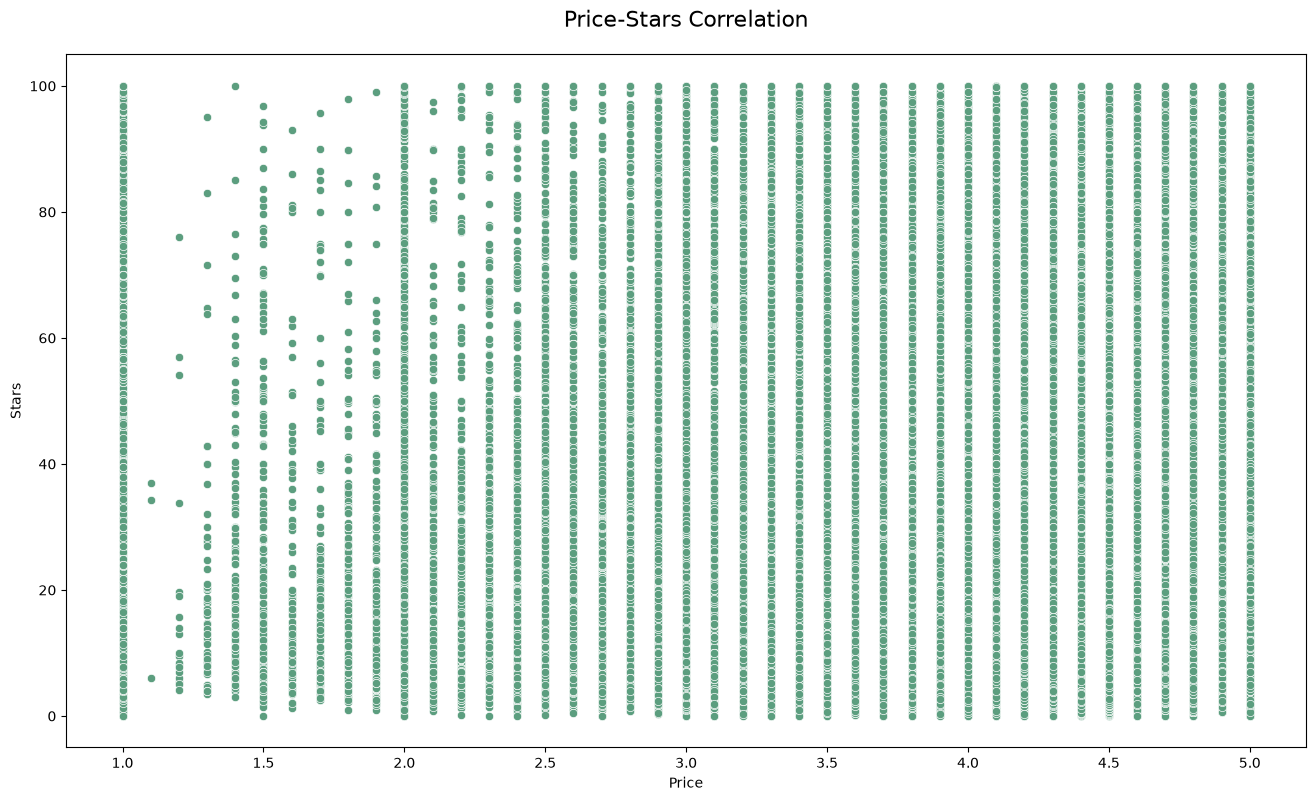

In [23]:
plt.figure(figsize = (16,9))

sns.scatterplot(
    data = clean_rating,
    x = "stars",
    y = "price",
    color = "#5C9E7F"
)

plt.title(r"Price-Stars Correlation", fontsize = 16, pad = 20)
plt.ylabel("Stars")
plt.xlabel("Price")

plt.show()

In [24]:
df_numerical = clean_rating.select_dtypes(include = ["number"]) #Filter only the columns with numerical values
df_numerical = df_numerical.drop(columns= ["uid"])
df_numerical = df_numerical.corr()

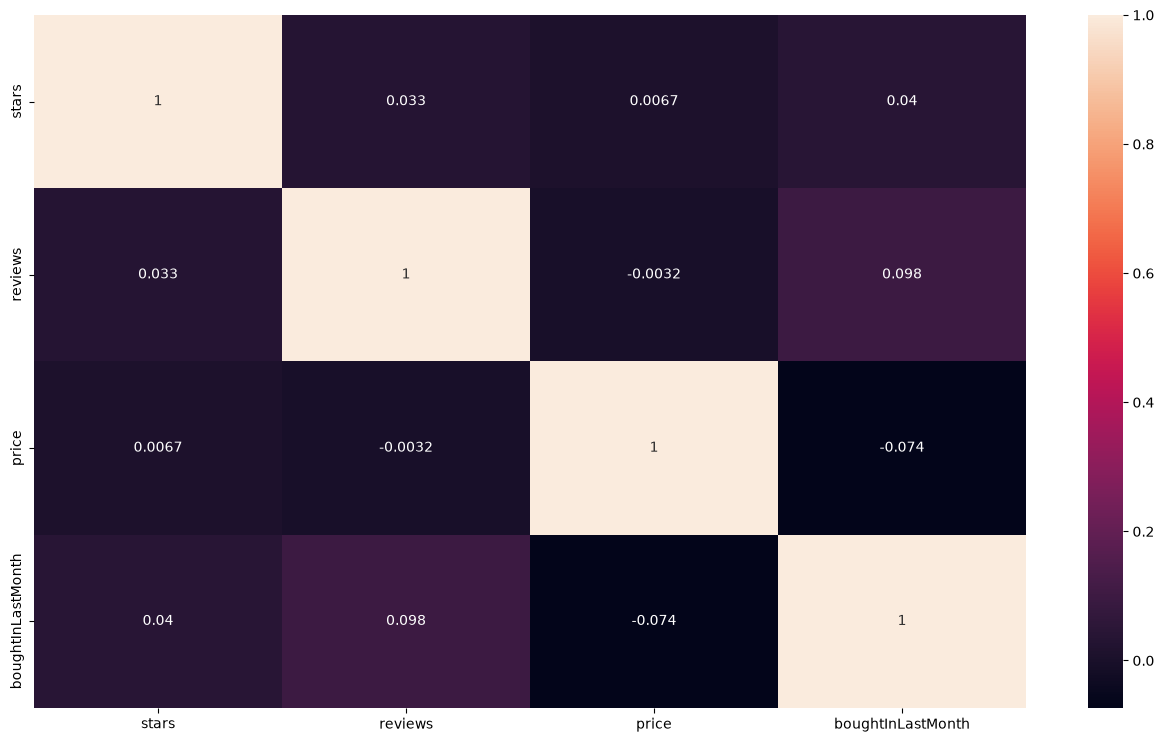

In [26]:
plt.figure(figsize = (16,9))

sns.heatmap(
    data = df_numerical,
    annot = True,
    color = "#5C9E7F"
)

plt.show()

In [36]:
import statsmodels.api as sm

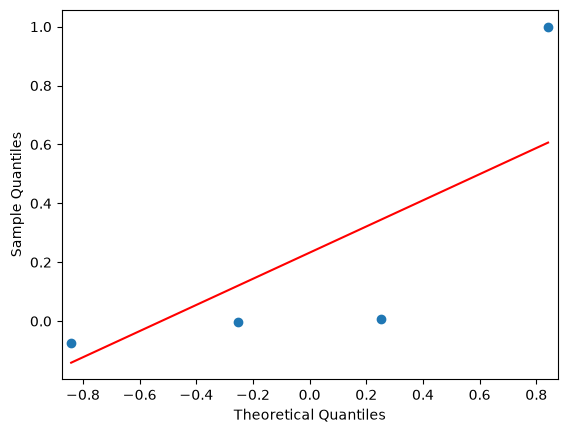

In [41]:
sm.qqplot(
    df_numerical["price"],
    line = "s"
)

plt.show()

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?